<a href="https://colab.research.google.com/github/ireshvithanage/Statistical-Learning-e22410/blob/main/Assingment_7_Kalman_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 7 : Kalman Filter**
---
B. V. I. D. Vithanage - E/22/410

---

## **1. State Prediction Statistics**

The predicted state $x_k^{-}$ is expressed as a linear combination of the previous updated state $x_{k-1}^{+}$ and the process noise $w_{k-1}$. Since both terms are Gaussian and the transformation is linear, $x_k^{-}$ is also Gaussian.

---

### **Mean ($m_k^{-}$)**

\[
$m_k^{-} = \mathbb{E}[x_k^{-}] = \mathbb{E}\left[A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}\right]$
\]

Using linearity of expectation:

\[
$m_k^{-} = A_{k-1}\mathbb{E}[x_{k-1}^{+}] + G_{k-1}\mathbb{E}[w_{k-1}]$
\]

Since:
- $\mathbb{E}[x_{k-1}^{+}] = m_{k-1}$
- $\mathbb{E}[w_{k-1}] = 0$

we obtain:

\[
$m_k^{-} = A_{k-1} m_{k-1}$
\]

---

### **Covariance ($P_k^{-}$)**

\[
$P_k^{-} = \text{Cov}(x_k^{-}) = \text{Cov}\left(A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}\right)$
\]

Using covariance transformation rules and independence assumptions:

\[
$P_k^{-} = A_{k-1} P_{k-1} A_{k-1}^{T} + G_{k-1} \Sigma_p G_{k-1}^{T}$
\]

where:
- $P_{k-1} = \text{Cov}(x_{k-1}^{+})$
- $\Sigma_p = \text{Cov}(w_{k-1})$

---

### **Final Result**

\[
$
P_k^{-} = A_{k-1} P_{k-1} A_{k-1}^{T} + G_{k-1} \Sigma_p G_{k-1}^{T}$
\]
```

## **2.Measurement Prediction Statistics**

The predicted observation $y_k^{-}$ is a linear transformation of the predicted state $x_k^{-}$ with added measurement noise $z_k$. Since both $x_k^{-}$ and $z_k$ are Gaussian and independent, their linear combination is also Gaussian.

---

### **Mean**

\[
$\mathbb{E}[y_k^{-}] = \mathbb{E}[H_k x_k^{-} + z_k]$
\]

Using linearity of expectation:

\[
$\mathbb{E}[y_k^{-}] = H_k \mathbb{E}[x_k^{-}] + \mathbb{E}[z_k]$
\]

Substituting:
- $\mathbb{E}[x_k^{-}] = m_k^{-}$
- $\mathbb{E}[z_k] = 0$

we obtain:

\[
$\mathbb{E}[y_k^{-}] = H_k m_k^{-}$
\]

---

### **Covariance**

Given that $x_k^{-}$ and $z_k$ are independent:

\[
$\text{Cov}(y_k^{-}) = \text{Cov}(H_k x_k^{-} + z_k)$
\]

Applying covariance propagation rules:

\[
$\text{Cov}(y_k^{-}) = H_k \text{Cov}(x_k^{-}) H_k^T + \text{Cov}(z_k)$
\]

Substituting:
- $\text{Cov}(x_k^{-}) = P_k^{-}$
- $\text{Cov}(z_k) = \Sigma_m$

we get:

\[
$\text{Cov}(y_k^{-}) = H_k P_k^{-} H_k^T + \Sigma_m$
\]

---

### **Final Result**

\[
$\text{Cov}(y_k^{-}) = H_k P_k^{-} H_k^T + \Sigma_m$
\]

## **3. Joint Gaussian Distribution of State and Measurement**

Consider the joint random vector:

\
$V =
\begin{bmatrix}
x_k^{-} \\
y_k^{-}
\end{bmatrix}
$

Since both $x_k^{-}$ and $y_k^{-}$ are Gaussian and linearly related, their joint distribution is also Gaussian.

---

### **Mean Vector**

\
$mu_V =
\begin{bmatrix}
\mathbb{E}[x_k^{-}] \\
\mathbb{E}[y_k^{-}]
\end{bmatrix}$
=
$\begin{bmatrix}
m_k^{-} \\
H_k m_k^{-}
\end{bmatrix}
\$

---

### **Covariance Matrix (Block Form)**

\
$\Sigma_V =
\begin{bmatrix}
\Sigma_{xx} & \Sigma_{xy} \\
\Sigma_{yx} & \Sigma_{yy}
\end{bmatrix}$


where:

- \$(\Sigma_{xx} = \text{Cov}(x_k^{-}) = P_k^{-}\$)
- \$(\Sigma_{yy} = \text{Cov}(y_k^{-}) = H_k P_k^{-} H_k^T + \Sigma_m\$)

---

### **Cross-Covariance Term**

The cross-covariance is defined as:

\$
\Sigma_{xy} = \mathbb{E}\left[(x_k^{-} - m_k^{-})(y_k^{-} - H_k m_k^{-})^T\right]
\$

Using the measurement model:

\$
y_k^{-} = H_k x_k^{-} + z_k
\$

we rewrite:

\$
y_k^{-} - H_k m_k^{-} = H_k(x_k^{-} - m_k^{-}) + z_k
\$

Substituting:

\$
\Sigma_{xy} =
\mathbb{E}\left[(x_k^{-} - m_k^{-})(H_k(x_k^{-} - m_k^{-}) + z_k)^T\right]
\$

Expanding:

\$
\Sigma_{xy} =
\mathbb{E}\left[(x_k^{-} - m_k^{-})(x_k^{-} - m_k^{-})^T H_k^T\right]
+
\mathbb{E}\left[(x_k^{-} - m_k^{-}) z_k^T\right]
\$

Since $x_k^{-}$ and $z_k$ are independent:

\$
\mathbb{E}\left[(x_k^{-} - m_k^{-}) z_k^T\right] = 0
\$

Thus:

\$
\Sigma_{xy} = \mathbb{E}\left[(x_k^{-} - m_k^{-})(x_k^{-} - m_k^{-})^T\right] H_k^T
= P_k^{-} H_k^T
\$

---

### **Symmetry Property**

\$
\Sigma_{yx} = \Sigma_{xy}^T = H_k P_k^{-}
\$

---

### **Final Joint Distribution**

 $$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

## **4. Kalman Gain and State Update**

From the joint Gaussian formulation, the Kalman Gain is defined as:

\$
K_k = \Sigma_{xy} \Sigma_{yy}^{-1}
\$

Substituting the expressions for the covariance blocks:

\$
K_k = P_k^{-} H_k^T \left(H_k P_k^{-} H_k^T + \Sigma_m \right)^{-1}
\$

---

### **Updated State Mean**

The posterior (updated) mean is given by:

\$
m_k = m_k^{-} + K_k \left(y_k^{\mathrm{obs}} - H_k m_k^{-}\right)
\$

where:
- $y_k^{\mathrm{obs}}$ is the observed measurement
- $(y_k^{\mathrm{obs}} - H_k m_k^{-})$ is the innovation (measurement residual)

---

### **Updated Covariance**

The posterior covariance is:

\$
P_k = P_k^{-} - K_k (H_k P_k^{-})
\$

Factoring the expression gives the compact form:

\$
P_k = (I - K_k H_k) P_k^{-}
\$

---

### **Final Summary**

\${
K_k = P_k^{-} H_k^T \left(H_k P_k^{-} H_k^T + \Sigma_m \right)^{-1}
}
\$

\${
m_k = m_k^{-} + K_k (y_k^{\mathrm{obs}} - H_k m_k^{-})
}
\$

\${
P_k = (I - K_k H_k) P_k^{-}
}
\$

## **5. Conditional Distribution (Kalman Update Form)**

Given the joint Gaussian structure, the conditional distribution of the state given the observation is also Gaussian.

---

### **1. Conditional Mean (Expected Value)**

$$\mathbb{E}(x_k^{-} \mid y_k^{-} = y_k^{\mathrm{obs}}) = m_k = m_k^{-} + K_k (y_k^{\mathrm{obs}} - H_k m_k^{-})$$

---

### **2. Conditional Covariance (Variance)**

$$\mathrm{Var}(x_k^{-} \mid y_k^{-} = y_k^{\mathrm{obs}}) = P_k = (I - K_k H_k) P_k^{-}$$

---

### **Final Interpretation**

After incorporating the observation $y_k^{\mathrm{obs}}$, the prior state distribution updates to a posterior Gaussian with:

- updated mean shifted toward the measurement
- reduced uncertainty due to the observation information


## **Q2) 1-D Example**

### **1. State Prediction (Scalar Case)**

The predicted state $x_k^{-}$ is a linear combination of the previous updated state $x_{k-1}^{+}$ and process noise $w_{k-1}$. Since the process noise is independent of the state and has zero mean, the prediction statistics simplify as follows.



### **Mean ($m_k^{-}$)**

Because $x_{k-1}^{+}$ and $w_{k-1}$ are independent and $\mathbb{E}(w_{k-1}) = 0$:

$m_k^{-} = \mathbb{E}(x_k^{-}) = \mathbb{E}(a x_{k-1}^{+} + w_{k-1})$

$m_k^{-} = a \mathbb{E}(x_{k-1}^{+}) + \mathbb{E}(w_{k-1})$

$m_k^{-} = a m_{k-1}$



### **Variance ($P_k^{-}$)**

The variance of the predicted state is:

$P_k^{-} = \mathrm{Var}(x_k^{-}) = \mathrm{Var}(a x_{k-1}^{+} + w_{k-1})$

Using independence of terms:

$P_k^{-} = a^2 \mathrm{Var}(x_{k-1}^{+}) + \mathrm{Var}(w_{k-1})$

Substituting:
- $\mathrm{Var}(x_{k-1}^{+}) = P_{k-1}$
- $\mathrm{Var}(w_{k-1}) = q$

we obtain:

$P_k^{-} = a^2 P_{k-1} + q$

---

### **4. Scalar Kalman Filter Update**

First, define the innovation (residual) variance:

$S_k = h P_k^{-} h^T + \Sigma_m$

Since this is a scalar case:

$S_k = h^2 P_k^{-} + r$



### **Kalman Gain**

Substituting into the Kalman gain expression:

$K_k = P_k^{-} h^T (S_k)^{-1}$

$K_k = \frac{P_k^{-} h}{S_k}$



### **Innovation**

The innovation (measurement residual) is:

$v_k = y_k^{\mathrm{obs}} - h m_k^{-}$



### **Updated Mean**

The posterior mean becomes:

$m_k = m_k^{-} + K_k v_k$

Substituting $K_k$:

$m_k = m_k^{-} + \frac{P_k^{-} h}{S_k} (y_k^{\mathrm{obs}} - h m_k^{-})$



### **Updated Variance**

The covariance update is:

$P_k = (1 - K_k h) P_k^{-}$

Substituting $K_k = \frac{P_k^{-} h}{S_k}$:

$P_k = \left(1 - \frac{P_k^{-} h^2}{S_k} \right) P_k^{-}$

---

### **3. Measurement Prediction (Scalar Case)**

The predicted measurement $y_k^{-}$ depends on the predicted state $x_k^{-}$ and measurement noise $z_k$. Since both terms are Gaussian and independent, the resulting distribution is also Gaussian.



### **Mean**

$\mathbb{E}(y_k^{-} \mid Y_{k-1}) = \mathbb{E}(h x_k^{-} + z_k)$

Using linearity of expectation:

$\mathbb{E}(y_k^{-} \mid Y_{k-1}) = h \mathbb{E}(x_k^{-}) + \mathbb{E}(z_k)$

Since $\mathbb{E}(x_k^{-}) = m_k^{-}$ and $\mathbb{E}(z_k) = 0$:

$\mathbb{E}(y_k^{-} \mid Y_{k-1}) = h m_k^{-}$



### **Variance**

Because $x_k^{-}$ and $z_k$ are independent:

$\mathrm{Var}(y_k^{-} \mid Y_{k-1}) = \mathrm{Var}(h x_k^{-} + z_k)$

Applying variance rules:

$\mathrm{Var}(y_k^{-} \mid Y_{k-1}) = h^2 \mathrm{Var}(x_k^{-}) + \mathrm{Var}(z_k)$

Substituting:
- $\mathrm{Var}(x_k^{-}) = P_k^{-}$
- $\mathrm{Var}(z_k) = r$

we obtain:

$\mathrm{Var}(y_k^{-} \mid Y_{k-1}) = h^2 P_k^{-} + r$


### **Final Distribution**

$p(y_k^{-} \mid Y_{k-1}) = \mathcal{N}(h m_k^{-}, h^2 P_k^{-} + r)$

---

### **4. Measurement Distribution (Updated State Case)**

The random variable $\tilde{y}_k$ depends on the posterior state $x_k$ and measurement noise $z_k$. Since the noise is zero-mean Gaussian and independent of the state, the resulting distribution is Gaussian.



### **Mean**

$\mathbb{E}(\tilde{y}_k \mid Y_k) = \mathbb{E}(h x_k + z_k)$

Using linearity of expectation:

$\mathbb{E}(\tilde{y}_k \mid Y_k) = h \mathbb{E}(x_k) + \mathbb{E}(z_k)$

Since $\mathbb{E}(x_k) = m_k$ and $\mathbb{E}(z_k) = 0$:

$\mathbb{E}(\tilde{y}_k \mid Y_k) = h m_k$



### **Variance**

$\mathrm{Var}(\tilde{y}_k \mid Y_k) = \mathrm{Var}(h x_k + z_k)$

Using independence:

$\mathrm{Var}(\tilde{y}_k \mid Y_k) = h^2 \mathrm{Var}(x_k) + \mathrm{Var}(z_k)$

Substituting:
- $\mathrm{Var}(x_k) = P_k$
- $\mathrm{Var}(z_k) = r$

we get:

$\mathrm{Var}(\tilde{y}_k \mid Y_k) = h^2 P_k + r$



### **Final Distribution**

$p(\tilde{y}_k \mid Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$

---

Here is your updated code with **changed graph colors + slightly improved legend styling**:

* Prior → **blue**
* Likelihood → **orange**
* Posterior → **green**
* Legend moved to top and made cleaner

```python
# @title 2.5 Kalman Filter Animation (1D Case)

import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

# -----------------------------
# Model Parameters
# -----------------------------
a, q = 1.0, 1.0
h, r = 1.0, 2.0

m, P = 0.0, 5.0
steps = 15

# -----------------------------
# Initialization
# -----------------------------
np.random.seed(42)

x_true = 0.0
x_grid = np.linspace(-15, 15, 500)

frames = []

# -----------------------------
# Kalman Filter Loop
# -----------------------------
for k in range(steps):

    # Prediction
    m_pred = a * m
    P_pred = (a ** 2) * P + q

    # True system + measurement
    x_true = a * x_true + np.random.normal(0, np.sqrt(q))
    y_obs = h * x_true + np.random.normal(0, np.sqrt(r))

    # Update
    S = (h ** 2) * P_pred + r
    K = (P_pred * h) / S

    m = m_pred + K * (y_obs - h * m_pred)
    P = (1 - K * h) * P_pred

    # PDFs
    prior_pdf = norm.pdf(x_grid, m_pred, np.sqrt(P_pred))
    post_pdf = norm.pdf(x_grid, m, np.sqrt(P))
    likelihood_pdf = norm.pdf(x_grid, y_obs / h, np.sqrt(r) / h)

    frames.append(
        go.Frame(
            data=[
                go.Scatter(
                    x=x_grid,
                    y=prior_pdf,
                    mode='lines',
                    name='Prior belief',
                    line=dict(color='royalblue', dash='dash')
                ),
                go.Scatter(
                    x=x_grid,
                    y=likelihood_pdf,
                    mode='lines',
                    name='Measurement likelihood',
                    line=dict(color='darkorange', dash='dot')
                ),
                go.Scatter(
                    x=x_grid,
                    y=post_pdf,
                    mode='lines',
                    name='Posterior belief',
                    line=dict(color='seagreen', width=3)
                )
            ],
            name=f"Step {k}"
        )
    )

# -----------------------------
# Figure
# -----------------------------
fig = go.Figure(
    data=[
        go.Scatter(x=x_grid, y=frames[0].data[0].y,
                   mode='lines', name='Prior belief',
                   line=dict(color='royalblue', dash='dash')),

        go.Scatter(x=x_grid, y=frames[0].data[1].y,
                   mode='lines', name='Measurement likelihood',
                   line=dict(color='darkorange', dash='dot')),

        go.Scatter(x=x_grid, y=frames[0].data[2].y,
                   mode='lines', name='Posterior belief',
                   line=dict(color='seagreen'))
    ],
    layout=go.Layout(
        title="1D Kalman Filter: Prior vs Posterior Evolution",
        template="plotly_dark",
        xaxis=dict(range=[-15, 15], title="State Space (x)"),
        yaxis=dict(range=[0, 0.6], title="Probability Density"),

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),

        updatemenus=[dict(
            type="buttons",
            buttons=[dict(
                label="Play",
                method="animate",
                args=[None, dict(frame=dict(duration=1000, redraw=True),
                                fromcurrent=True)]
            )]
        )]
    ),
    frames=frames
)

fig.show()
```


## **Q3) 2-D Estimation**

The hidden state vector is defined as:

$
x_k =
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
$

where:
- $p_x(k), p_y(k)$ represent the position components,
- $v_x(k), v_y(k)$ represent the velocity components.

---

The measurement vector is:

$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k) \\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
$

---

The system dynamics are given by:

$
x_k^{-} = A x_{k-1}^{+} + G w_{k-1}
$

and the measurement model is:

$
y_k^{-} = H x_k^{-} + z_k
$

---

# **Step 1: State Transition Matrix $A$**

For a constant-velocity motion model:

$
p_x(k) = p_x(k-1) + \Delta t \, v_x(k-1)
$

$
p_y(k) = p_y(k-1) + \Delta t \, v_y(k-1)
$

Velocity is assumed constant between consecutive time steps:

$
v_x(k) = v_x(k-1), \quad v_y(k) = v_y(k-1)
$

These equations can be written in matrix form as:

$
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix}
$

Therefore:

$
{
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
}
$

---

# **Step 2: Measurement Matrix $H$**

The sensor measures only position:

$
y_k =
\begin{bmatrix}
p_x(k) \\
p_y(k)
\end{bmatrix}
$

Since velocity is not observed directly:

$
p_x(k) =
\begin{bmatrix}
1 & 0 & 0 & 0
\end{bmatrix}
x_k,
\quad
p_y(k) =
\begin{bmatrix}
0 & 1 & 0 & 0
\end{bmatrix}
x_k
$

Combining both gives:

$
y_k =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
x_k
$

Thus:

$
{
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
}
$

---

# **Step 3: Process Noise Matrix $G$**

Let the process noise represent unknown acceleration:

$
w_k =
\begin{bmatrix}
a_x \\
a_y
\end{bmatrix}
$

From kinematics:

$
\Delta p = \frac{1}{2} a (\Delta t)^2,
\quad
\Delta v = a \Delta t
$

Applying this independently in both directions:

$
\begin{aligned}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2} a_x (\Delta t)^2 \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2} a_y (\Delta t)^2 \\
v_x(k) &= v_x(k-1) + a_x \Delta t \\
v_y(k) &= v_y(k-1) + a_y \Delta t
\end{aligned}
$

Grouping acceleration terms:

$
G w_k =
\begin{bmatrix}
\frac{1}{2} (\Delta t)^2 & 0 \\
0 & \frac{1}{2} (\Delta t)^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x \\
a_y
\end{bmatrix}
$

Therefore:

$
{
G =
\begin{bmatrix}
\frac{1}{2} \Delta t^2 & 0 \\
0 & \frac{1}{2} \Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
}
$

---

# **Final Result**

$
{
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
}
\quad
{
H =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
}
\quad
{
G =
\begin{bmatrix}
\frac{1}{2} \Delta t^2 & 0 \\
0 & \frac{1}{2} \Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
}
$

These matrices define the motion model, measurement model, and process noise structure for a 2D constant-velocity Kalman filter.

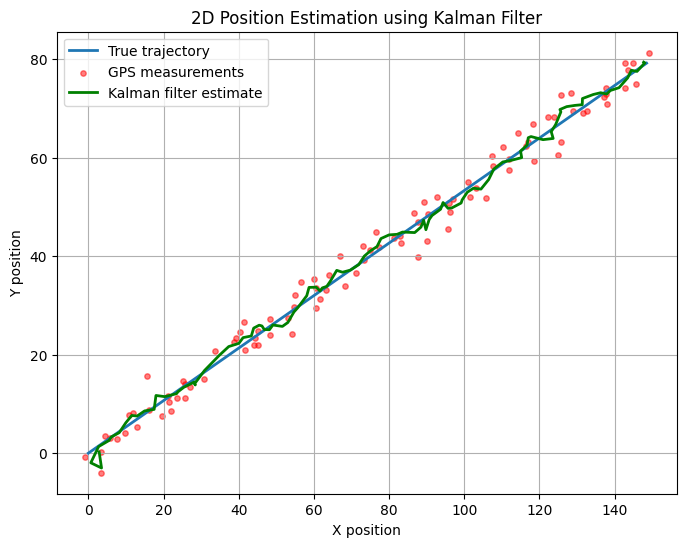

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 2D Constant-Velocity Model: Synthetic GPS Data Generation
# ------------------------------------------------------------------

np.random.seed(10)

dt = 1.0
N = 100  # number of time steps

# -----------------------------
# True state trajectory
# -----------------------------
true_state = np.zeros((4, N))

# initial state: [x, y, vx, vy]
true_state[:, 0] = [0, 0, 1.5, 0.8]

for k in range(1, N):
    true_state[0, k] = true_state[0, k-1] + dt * true_state[2, k-1]
    true_state[1, k] = true_state[1, k-1] + dt * true_state[3, k-1]
    true_state[2, k] = true_state[2, k-1]
    true_state[3, k] = true_state[3, k-1]

# -----------------------------
# Noisy GPS measurements
# -----------------------------
gps_std = 2.5

measurements = np.zeros((2, N))
measurements[0] = true_state[0] + np.random.normal(0, gps_std, N)
measurements[1] = true_state[1] + np.random.normal(0, gps_std, N)

# -------------------------
# Kalman Filter Model Matrices
# -------------------------

A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

G = np.array([
    [0.5 * dt**2, 0],
    [0, 0.5 * dt**2],
    [dt, 0],
    [0, dt]
])

# -----------------------------
# Noise covariances
# -----------------------------
sigma_acc = 0.2
Q = (sigma_acc ** 2) * np.eye(2)   # process noise

R = (gps_std ** 2) * np.eye(2)     # measurement noise

# -------------------------
# Initialization
# -------------------------

x = np.array([0, 0, 0, 0], dtype=float)  # initial state estimate
P = np.eye(4) * 20                       # initial uncertainty

filtered_state = np.zeros((4, N))

# -------------------------
# Kalman Filter Loop
# -------------------------

for k in range(N):

    # -------------------------
    # Prediction step
    # -------------------------
    x_pred = A @ x
    P_pred = A @ P @ A.T + G @ Q @ G.T

    # -------------------------
    # Measurement update
    # -------------------------
    y = measurements[:, k]

    innovation = y - H @ x_pred
    S = H @ P_pred @ H.T + R

    K = P_pred @ H.T @ np.linalg.inv(S)

    x = x_pred + K @ innovation
    P = (np.eye(4) - K @ H) @ P_pred

    filtered_state[:, k] = x

# -------------------------
# Visualization
#-------------------------

plt.figure(figsize=(8, 6))

# True path
plt.plot(true_state[0], true_state[1],
         label="True trajectory",
         linewidth=2)

# Noisy GPS
plt.scatter(measurements[0], measurements[1],
            color="red",
            s=15,
            alpha=0.5,
            label="GPS measurements")

# Kalman estimate
plt.plot(filtered_state[0], filtered_state[1],
         color="green",
         linewidth=2,
         label="Kalman filter estimate")

plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D Position Estimation using Kalman Filter")

plt.grid(True)
plt.legend()
plt.show()